# 🔬 Visualization Mini-Lab: Trends and Outliers

Now it’s time to put your skills to the test. In this mini-lab, you’ll explore a real dataset, create visualizations, and identify trends and outliers.

We’ll use the Penguins dataset.


## Setup

Run this cell first if your environment is missing packages.


In [1]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Optional fallback import
try:
    import seaborn as sns
except Exception:
    sns = None

## Load dataset

This tries to load `../../data/penguins.csv` first.  
If that file is missing, it falls back to Seaborn's built-in penguins dataset.


In [3]:
from pathlib import Path

csv_path = Path("../../data/penguins.csv")

if csv_path.exists():
    penguins = pd.read_csv(csv_path)
elif sns is not None:
    penguins = sns.load_dataset("penguins")
else:
    raise FileNotFoundError("Could not find ../../data/penguins.csv and seaborn is unavailable.")

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 1. Explore Distributions

First, look at the distribution of body mass.


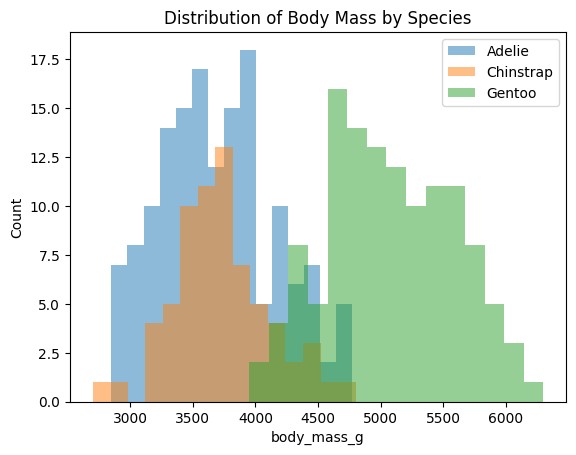

In [4]:
species_list = penguins["species"].dropna().unique()

for species in species_list:
    subset = penguins.loc[penguins["species"] == species, "body_mass_g"].dropna()
    plt.hist(subset, bins=15, alpha=0.5, label=species)

plt.title("Distribution of Body Mass by Species")
plt.xlabel("body_mass_g")
plt.ylabel("Count")
plt.legend()
plt.show()

### Task

Do some species have higher average body mass than others?


In [5]:
penguins.groupby("species")["body_mass_g"].mean().sort_values(ascending=False)

species
Gentoo       5076.016260
Chinstrap    3733.088235
Adelie       3700.662252
Name: body_mass_g, dtype: float64

## 2. Relationships Between Variables

Scatterplots help us see trends between two quantitative variables.


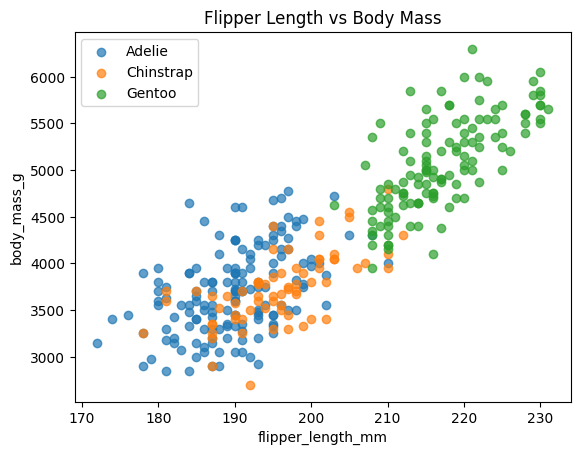

In [6]:
for species in species_list:
    subset = penguins[penguins["species"] == species]
    plt.scatter(subset["flipper_length_mm"], subset["body_mass_g"], alpha=0.7, label=species)

plt.title("Flipper Length vs Body Mass")
plt.xlabel("flipper_length_mm")
plt.ylabel("body_mass_g")
plt.legend()
plt.show()

### Task

Which species tends to have longer flippers and higher body mass?


In [7]:
penguins.groupby("species")[["flipper_length_mm", "body_mass_g"]].mean().sort_values(by=["flipper_length_mm", "body_mass_g"], ascending=False)

,flipper_length_mm,body_mass_g
species,,
Gentoo,217.186992,5076.016260
Chinstrap,195.823529,3733.088235
Adelie,189.953642,3700.662252


## 3. Box Plots for Outliers

Box plots are useful for spotting outliers.


/var/folders/4g/brtqy4696sq_j5rk22x4zvch0000gn/T/ipykernel_45303/408422689.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(bill_data, labels=species_list)


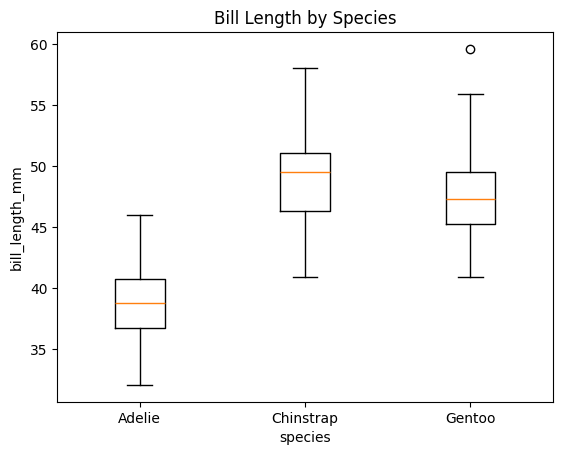

In [8]:
bill_data = [
    penguins.loc[penguins["species"] == species, "bill_length_mm"].dropna()
    for species in species_list
]

plt.boxplot(bill_data, labels=species_list)
plt.title("Bill Length by Species")
plt.xlabel("species")
plt.ylabel("bill_length_mm")
plt.show()

### Task

Can you spot any outliers in the bill length data?


In [9]:
# Compute possible outliers using the IQR rule for each species
outlier_rows = []

for species in species_list:
    vals = penguins.loc[penguins["species"] == species, "bill_length_mm"].dropna()
    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = penguins[(penguins["species"] == species) & ((penguins["bill_length_mm"] < lower) | (penguins["bill_length_mm"] > upper))]
    if not outliers.empty:
        outlier_rows.append(outliers[["species", "bill_length_mm"]])

if outlier_rows:
    pd.concat(outlier_rows)
else:
    print("No clear outliers found by the 1.5*IQR rule.")

## 4. Correlation Heatmap

Correlation heatmaps let us see overall numeric relationships.


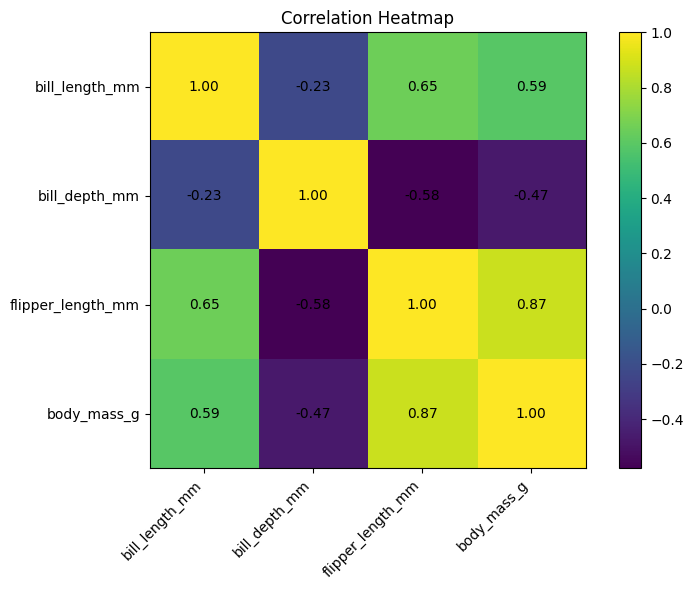

In [10]:
corr = penguins.dropna().corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Heatmap")
plt.colorbar(im)
plt.tight_layout()
plt.show()

### Task

Which variables appear to be strongly correlated?


In [11]:
corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


## 5. Your Turn

Try a different dataset and:
- create at least 2 plots that reveal a trend
- create 1 plot that highlights possible outliers
- write a short summary of your findings


In [12]:
# Example second dataset you can use right away
tips = pd.DataFrame({
    "total_bill": [16.99, 10.34, 21.01, 23.68, 24.59, 25.29, 8.77, 26.88, 15.04, 14.78],
    "tip": [1.01, 1.66, 3.50, 3.31, 3.61, 4.71, 2.00, 3.12, 1.96, 3.23],
    "size": [2, 3, 3, 2, 4, 4, 2, 4, 2, 2]
})

tips.head()

,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


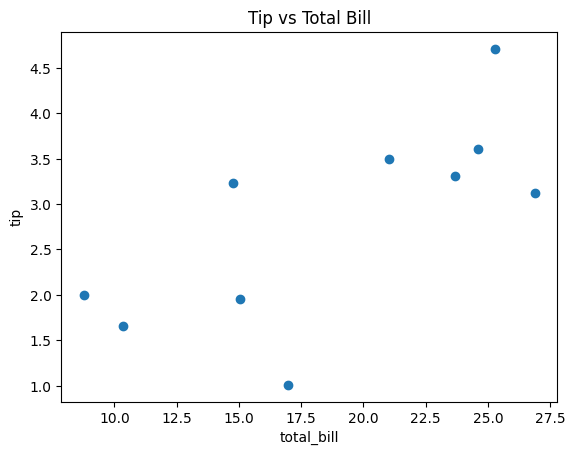

In [13]:
# Trend plot 1
plt.scatter(tips["total_bill"], tips["tip"])
plt.title("Tip vs Total Bill")
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.show()

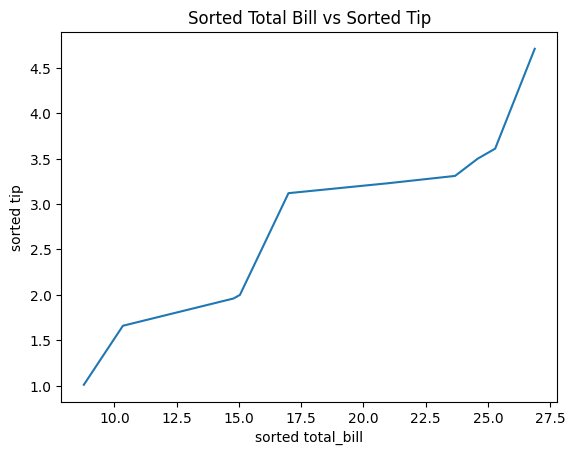

In [14]:
# Trend plot 2
plt.plot(sorted(tips["total_bill"]), sorted(tips["tip"]))
plt.title("Sorted Total Bill vs Sorted Tip")
plt.xlabel("sorted total_bill")
plt.ylabel("sorted tip")
plt.show()

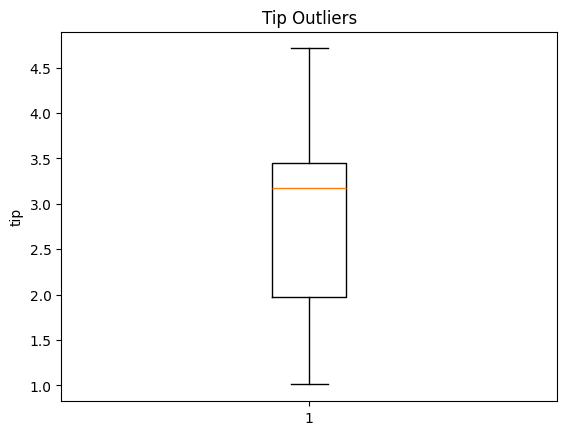

In [15]:
# Outlier plot
plt.boxplot(tips["tip"].dropna())
plt.title("Tip Outliers")
plt.ylabel("tip")
plt.show()

### Short Summary Example

In the penguins data, body mass and flipper length tend to increase together, and some species have clearly larger average body mass than others.  
The box plot helps identify unusually short or long bill lengths within species.  
The correlation heatmap summarizes which numeric measurements move together most strongly.


## ✅ Finished

You’ve completed the visualization mini-lab.

Next module: working with larger datasets and diving deeper into analysis.
